<a href="https://colab.research.google.com/github/EvADarya/Data_processing-DLS-/blob/main/lab_2_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

## Предобработка

In [ ]:
data = pd.read_csv("/content/Amazon_Stock_Price.csv")

Посмотрим на данные

In [ ]:
data.head()

,Unnamed: 0,Date,Open,High,Low,Close,Volume
0,0,2000-01-03,4.075000,4.478125,3.952344,4.468750,322352000
1,1,2000-01-04,4.268750,4.575000,4.087500,4.096875,349748000
2,2,2000-01-05,3.525000,3.756250,3.400000,3.487500,769148000
3,3,2000-01-06,3.565625,3.634375,3.200000,3.278125,375040000
4,4,2000-01-07,3.350000,3.525000,3.309375,3.478125,210108000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6050 entries, 0 to 6049
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  6050 non-null   int64  
 1   Date        6050 non-null   object 
 2   Open        6050 non-null   float64
 3   High        6050 non-null   float64
 4   Low         6050 non-null   float64
 5   Close       6050 non-null   float64
 6   Volume      6050 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 331.0+ KB


Преобразуем столбец с датой

In [ ]:
data['Date'] = pd.to_datetime(data['Date'])

In [ ]:
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day

In [ ]:
data = data.drop(['Date', 'Unnamed: 0'], axis = 1)

In [ ]:
data.head()

,Open,High,Low,Close,Volume,Year,Month,Day
0,4.075000,4.478125,3.952344,4.468750,322352000,2000,1,3
1,4.268750,4.575000,4.087500,4.096875,349748000,2000,1,4
2,3.525000,3.756250,3.400000,3.487500,769148000,2000,1,5
3,3.565625,3.634375,3.200000,3.278125,375040000,2000,1,6
4,3.350000,3.525000,3.309375,3.478125,210108000,2000,1,7


<Axes: >

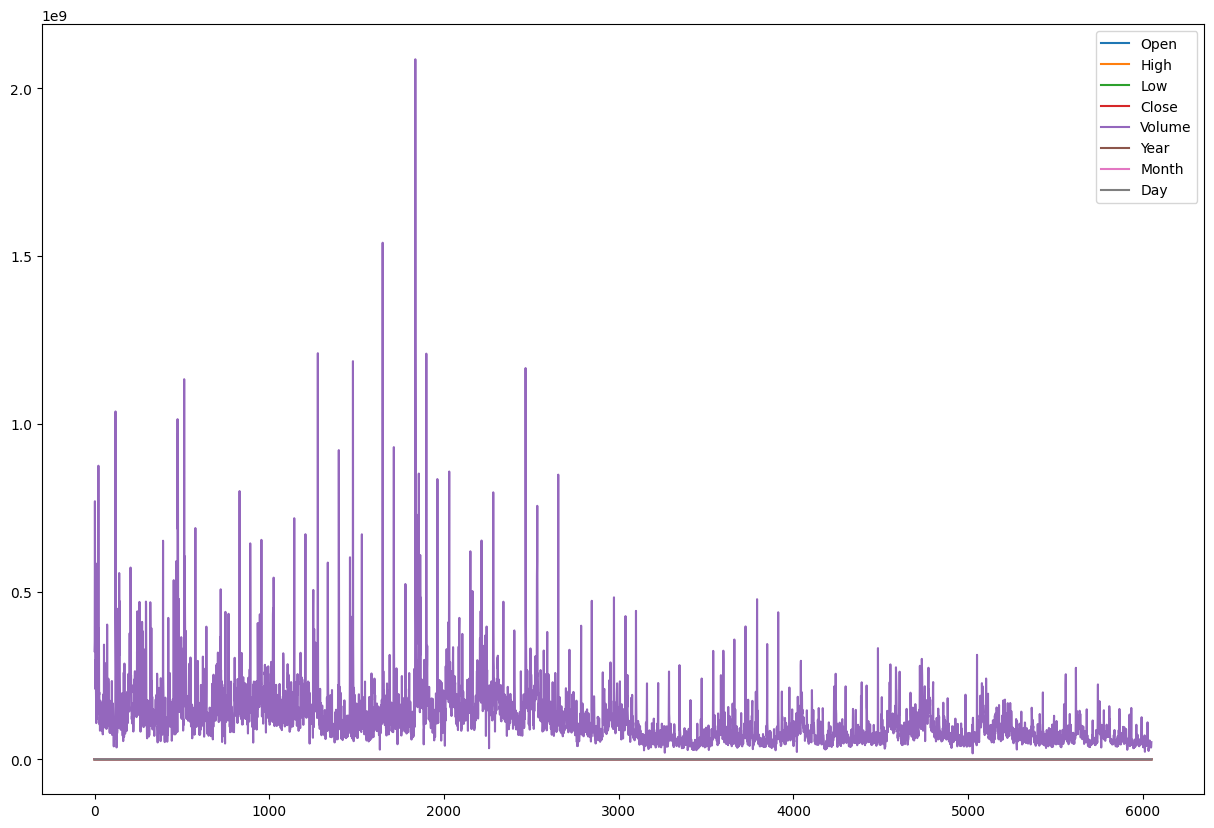

In [ ]:
data.plot(figsize = (15,10))

<Axes: >

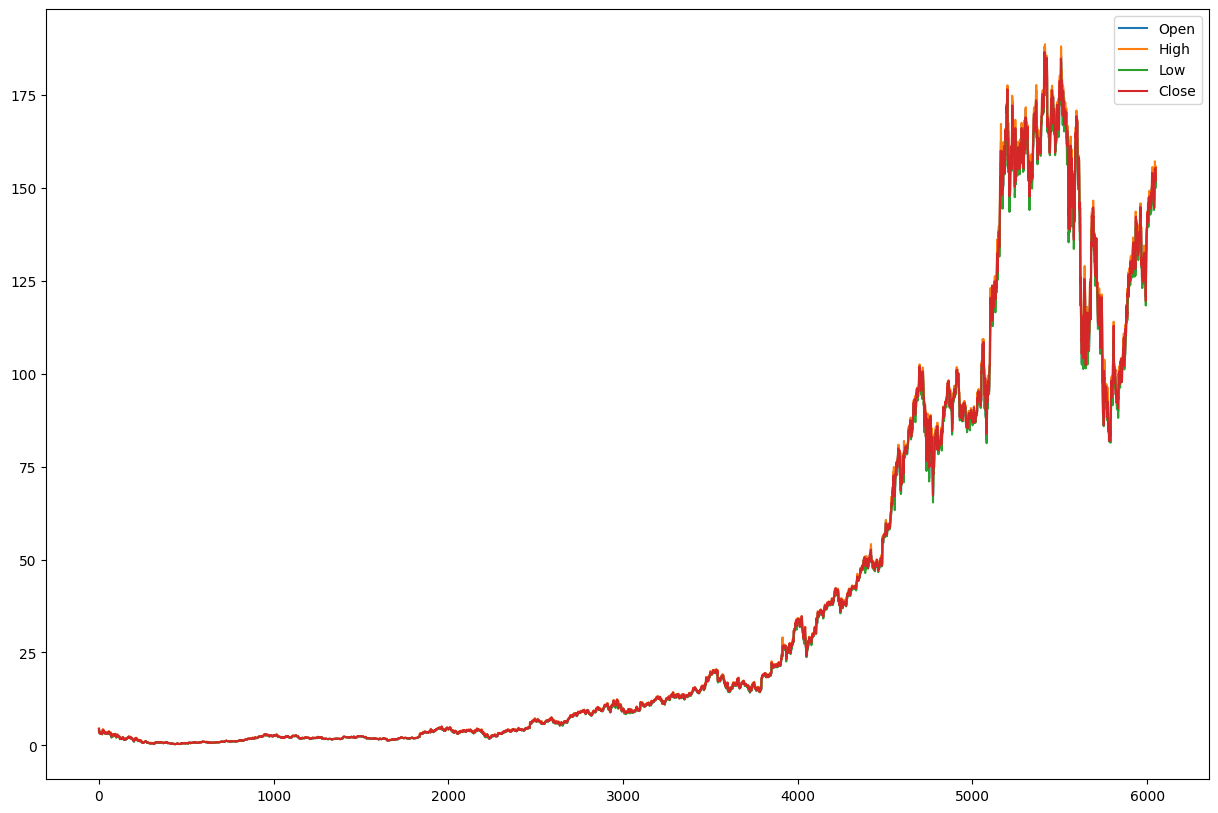

In [ ]:
df = data[['Open','High','Low','Close']]
df.plot(figsize = (15,10))

## Подготовка датасетов

In [ ]:
split = int(len(data) * 0.8)
train_data = data[:split]
test_data = data[split:]

In [ ]:
print(f"Train size: {len(train_data)}, Test size: {len(test_data)}")

Train size: 4840, Test size: 1210


In [ ]:
train_data.head()

,Open,High,Low,Close,Volume,Year,Month,Day
0,4.075000,4.478125,3.952344,4.468750,322352000,2000,1,3
1,4.268750,4.575000,4.087500,4.096875,349748000,2000,1,4
2,3.525000,3.756250,3.400000,3.487500,769148000,2000,1,5
3,3.565625,3.634375,3.200000,3.278125,375040000,2000,1,6
4,3.350000,3.525000,3.309375,3.478125,210108000,2000,1,7


Проведём стандартизацию обучающего датасета для улучшеиия сходимости

In [ ]:
scaler = MinMaxScaler()
train_scaled_data = scaler.fit_transform(train_data)
test_scaled_data = scaler.transform(test_data)

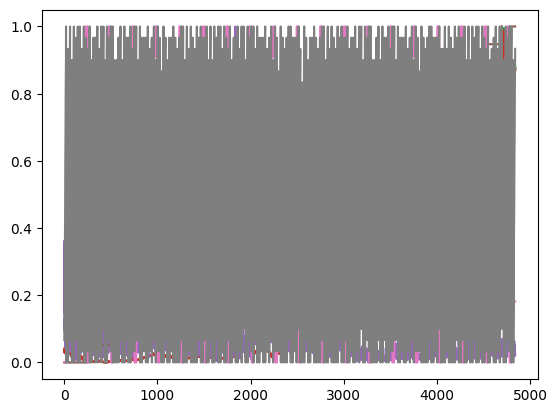

In [ ]:
plt.plot(train_scaled_data)

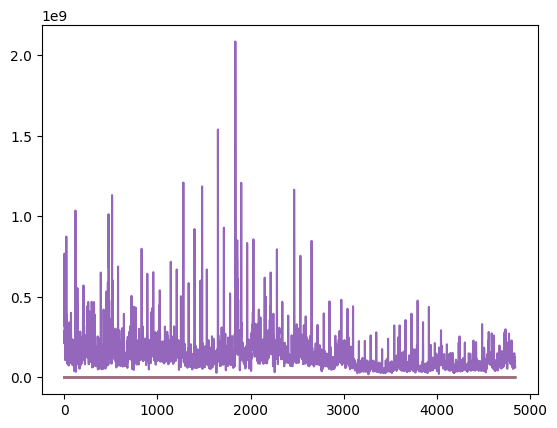

In [ ]:
plt.plot(train_data)

Делаем окна предсказания 30 значений + 31 - предсказание - идём такими скользящими окнами, чтобы получались предсказания временного ряда

In [ ]:
X_train = []
y_train = []
for i in range(60,len(train_scaled_data)):
    X_train.append(train_scaled_data[i-30:i,0])
    y_train.append(train_scaled_data[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [ ]:
len(X_train), len(y_train)

(4780, 4780)

In [ ]:
test_data_full = np.vstack((train_scaled_data[-30:], test_data))

In [ ]:
X_test, y_test = [], []
for i in range(30, len(test_data)):
    X_test.append(test_scaled_data[i-30:i, 0])
    y_test.append(test_scaled_data[i, 0])

X_test = np.array(X_test).reshape(-1, 30, 1)
y_test = np.array(y_test)

test_dataset = TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test))
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
X_train[0]

array([0.03322877, 0.03289046, 0.03215235, 0.03076838, 0.02904611,
       0.02901535, 0.03181404, 0.0302763 , 0.02984573, 0.02956894,
       0.03036856, 0.02904611, 0.02821573, 0.0280312 , 0.02901535,
       0.02821573, 0.02809271, 0.03018404, 0.02858478, 0.02959969,
       0.02895384, 0.02772365, 0.02959969, 0.02833874, 0.02913837,
       0.03196782, 0.03129121, 0.03381311, 0.03264442, 0.03270593])

In [ ]:
y_train[0]

np.float64(0.03129120974438087)

In [ ]:
X_train = X_train.reshape(-1, 30, 1)
X_tensor = torch.FloatTensor(X_train)
y_tensor = torch.FloatTensor(y_train).unsqueeze(1)  # -> (N, 1)

train_dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
device

device(type='cuda')

## Создание моделей

In [ ]:
class LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)

        out = out[:, -1, :]
        out = self.fc(out)
        return out

model_LSTM = LSTM().to(device)

In [ ]:
class GRU(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size,
                          hidden_size=hidden_size,
                          num_layers=num_layers,
                          batch_first=True,
                          dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out
model_GRU = GRU().to(device)

In [ ]:
class RNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.rnn = nn.RNN(input_size=input_size,
                          hidden_size=hidden_size,
                          num_layers=num_layers,
                          batch_first=True,
                          dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out
model_RNN = RNN().to(device)

## Обучение моделей

In [ ]:
def train_model(model, train_loader, epochs=50, lr=0.001, device='cpu'):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)

        avg_loss = train_loss / len(train_loader.dataset)
        history['train_loss'].append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | Train Loss: {avg_loss:.6f}")

    return model, history

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model_RNN.parameters(), lr=0.001)
epochs = 50

model_RNN.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        predictions = model_RNN(X_batch)
        loss = criterion(predictions, y_batch)

        loss.backward()

        # 🔥 Обрезка градиентов: обязательна для RNN/LSTM, чтобы избежать взрыва градиентов
        torch.nn.utils.clip_grad_norm_(model_RNN.parameters(), max_norm=1.0)

        optimizer.step()
        epoch_loss += loss.item() * X_batch.size(0)

    avg_loss = epoch_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.6f}")

Epoch 1/50 | Loss: 0.000053
Epoch 2/50 | Loss: 0.000045
Epoch 3/50 | Loss: 0.000047
Epoch 4/50 | Loss: 0.000049
Epoch 5/50 | Loss: 0.000047
Epoch 6/50 | Loss: 0.000044
Epoch 7/50 | Loss: 0.000045
Epoch 8/50 | Loss: 0.000049
Epoch 9/50 | Loss: 0.000045
Epoch 10/50 | Loss: 0.000055
Epoch 11/50 | Loss: 0.000041
Epoch 12/50 | Loss: 0.000038
Epoch 13/50 | Loss: 0.000041
Epoch 14/50 | Loss: 0.000047
Epoch 15/50 | Loss: 0.000046
Epoch 16/50 | Loss: 0.000045
Epoch 17/50 | Loss: 0.000044
Epoch 18/50 | Loss: 0.000048
Epoch 19/50 | Loss: 0.000041
Epoch 20/50 | Loss: 0.000042
Epoch 21/50 | Loss: 0.000044
Epoch 22/50 | Loss: 0.000045
Epoch 23/50 | Loss: 0.000041
Epoch 24/50 | Loss: 0.000044
Epoch 25/50 | Loss: 0.000042
Epoch 26/50 | Loss: 0.000042
Epoch 27/50 | Loss: 0.000044
Epoch 28/50 | Loss: 0.000040
Epoch 29/50 | Loss: 0.000043
Epoch 30/50 | Loss: 0.000038
Epoch 31/50 | Loss: 0.000046
Epoch 32/50 | Loss: 0.000044
Epoch 33/50 | Loss: 0.000039
Epoch 34/50 | Loss: 0.000043
Epoch 35/50 | Loss: 0.0

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model_LSTM.parameters(), lr=0.001)
epochs = 50

model_LSTM.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        predictions = model_LSTM(X_batch)
        loss = criterion(predictions, y_batch)

        loss.backward()

        # 🔥 Обрезка градиентов: обязательна для RNN/LSTM, чтобы избежать взрыва градиентов
        torch.nn.utils.clip_grad_norm_(model_LSTM.parameters(), max_norm=1.0)

        optimizer.step()
        epoch_loss += loss.item() * X_batch.size(0)

    avg_loss = epoch_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.6f}")

Epoch 1/50 | Loss: 0.010885
Epoch 2/50 | Loss: 0.000221
Epoch 3/50 | Loss: 0.000165
Epoch 4/50 | Loss: 0.000176
Epoch 5/50 | Loss: 0.000142
Epoch 6/50 | Loss: 0.000130
Epoch 7/50 | Loss: 0.000146
Epoch 8/50 | Loss: 0.000131
Epoch 9/50 | Loss: 0.000154
Epoch 10/50 | Loss: 0.000125
Epoch 11/50 | Loss: 0.000114
Epoch 12/50 | Loss: 0.000134
Epoch 13/50 | Loss: 0.000119
Epoch 14/50 | Loss: 0.000095
Epoch 15/50 | Loss: 0.000117
Epoch 16/50 | Loss: 0.000100
Epoch 17/50 | Loss: 0.000089
Epoch 18/50 | Loss: 0.000092
Epoch 19/50 | Loss: 0.000089
Epoch 20/50 | Loss: 0.000096
Epoch 21/50 | Loss: 0.000084
Epoch 22/50 | Loss: 0.000076
Epoch 23/50 | Loss: 0.000077
Epoch 24/50 | Loss: 0.000085
Epoch 25/50 | Loss: 0.000075
Epoch 26/50 | Loss: 0.000061
Epoch 27/50 | Loss: 0.000063
Epoch 28/50 | Loss: 0.000073
Epoch 29/50 | Loss: 0.000073
Epoch 30/50 | Loss: 0.000060
Epoch 31/50 | Loss: 0.000068
Epoch 32/50 | Loss: 0.000061
Epoch 33/50 | Loss: 0.000054
Epoch 34/50 | Loss: 0.000056
Epoch 35/50 | Loss: 0.0

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model_GRU.parameters(), lr=0.001)
epochs = 50

model_GRU.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        predictions = model_GRU(X_batch)
        loss = criterion(predictions, y_batch)

        loss.backward()

        # 🔥 Обрезка градиентов: обязательна для RNN/LSTM, чтобы избежать взрыва градиентов
        torch.nn.utils.clip_grad_norm_(model_GRU.parameters(), max_norm=1.0)

        optimizer.step()
        epoch_loss += loss.item() * X_batch.size(0)

    avg_loss = epoch_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.6f}")

Epoch 1/50 | Loss: 0.012147
Epoch 2/50 | Loss: 0.000083
Epoch 3/50 | Loss: 0.000088
Epoch 4/50 | Loss: 0.000086
Epoch 5/50 | Loss: 0.000065
Epoch 6/50 | Loss: 0.000079
Epoch 7/50 | Loss: 0.000073
Epoch 8/50 | Loss: 0.000074
Epoch 9/50 | Loss: 0.000062
Epoch 10/50 | Loss: 0.000066
Epoch 11/50 | Loss: 0.000062
Epoch 12/50 | Loss: 0.000072
Epoch 13/50 | Loss: 0.000060
Epoch 14/50 | Loss: 0.000057
Epoch 15/50 | Loss: 0.000061
Epoch 16/50 | Loss: 0.000053
Epoch 17/50 | Loss: 0.000056
Epoch 18/50 | Loss: 0.000061
Epoch 19/50 | Loss: 0.000051
Epoch 20/50 | Loss: 0.000057
Epoch 21/50 | Loss: 0.000066
Epoch 22/50 | Loss: 0.000051
Epoch 23/50 | Loss: 0.000047
Epoch 24/50 | Loss: 0.000053
Epoch 25/50 | Loss: 0.000055
Epoch 26/50 | Loss: 0.000045
Epoch 27/50 | Loss: 0.000051
Epoch 28/50 | Loss: 0.000062
Epoch 29/50 | Loss: 0.000051
Epoch 30/50 | Loss: 0.000052
Epoch 31/50 | Loss: 0.000051
Epoch 32/50 | Loss: 0.000046
Epoch 33/50 | Loss: 0.000048
Epoch 34/50 | Loss: 0.000048
Epoch 35/50 | Loss: 0.0

Валидация модели

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model, data_loader, device='cpu', scaler=None):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            pred = model(X_batch).cpu().numpy()

            y_true.extend(y_batch.numpy().flatten())
            y_pred.extend(pred.flatten())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    if scaler is not None:
        y_true = scaler.inverse_transform(y_true.reshape(-1, 1)).flatten()
        y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()


    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100  # +eps для стабильности
    r2 = r2_score(y_true, y_pred)

    return {
        'MSE': mse, 'RMSE': rmse, 'MAE': mae,
        'MAPE (%)': mape, 'R²': r2
    }

## Оценка

In [ ]:
models_dict = {'RNN': RNN(), 'GRU': GRU(), 'LSTM': LSTM()}

In [ ]:
def compare_models_on_test(models_dict, train_loader, test_loader,
                           device='cpu', scaler=None, epochs=50):
    results = []
    histories = {}

    for name, model in tqdm(models_dict.items(), desc="Training models"):
        print(f"\n🔹 Training {name}...")
        model = model.to(device)

        trained_model, history = train_model(
            model, train_loader, epochs=epochs, device=device
        )
        histories[name] = history

        # Оценка на тесте
        from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
        model.eval()
        y_true, y_pred = [], []

        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b = X_b.to(device)
                p = trained_model(X_b).cpu().numpy()
                y_true.extend(y_b.numpy().flatten())
                y_pred.extend(p.flatten())

        y_true, y_pred = np.array(y_true), np.array(y_pred)

        if scaler is not None:
            y_true = scaler.inverse_transform(y_true.reshape(-1, 1)).flatten()
            y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100
        r2 = r2_score(y_true, y_pred)

        results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'R²': r2})

    # 📊 Таблица результатов
    df = pd.DataFrame(results).set_index('Model')
    print("\n📈 Результаты на тестовой выборке:")
    print(df.round(6))

    # 📉 График обучения
    plt.figure(figsize=(10, 4))
    for name, hist in histories.items():
        plt.plot(hist['train_loss'], label=f'{name} Train')
    plt.xlabel('Epoch'), plt.ylabel('Train Loss (MSE)'), plt.legend(), plt.grid(True)
    plt.tight_layout()
    plt.show()

    return df, histories

Training models:   0%|          | 0/3 [00:00<?, ?it/s]


🔹 Training RNN...
Epoch  10 | Train Loss: 0.000044
Epoch  20 | Train Loss: 0.000041
Epoch  30 | Train Loss: 0.000040
Epoch  40 | Train Loss: 0.000039


Training models:  33%|███▎      | 1/3 [00:19<00:38, 19.36s/it]

Epoch  50 | Train Loss: 0.000042

🔹 Training GRU...
Epoch  10 | Train Loss: 0.000037
Epoch  20 | Train Loss: 0.000045
Epoch  30 | Train Loss: 0.000039
Epoch  40 | Train Loss: 0.000041


Training models:  67%|██████▋   | 2/3 [00:39<00:20, 20.11s/it]

Epoch  50 | Train Loss: 0.000038

🔹 Training LSTM...
Epoch  10 | Train Loss: 0.000042
Epoch  20 | Train Loss: 0.000043
Epoch  30 | Train Loss: 0.000039
Epoch  40 | Train Loss: 0.000039


Training models: 100%|██████████| 3/3 [01:01<00:00, 20.44s/it]

Epoch  50 | Train Loss: 0.000037

📈 Результаты на тестовой выборке:
           RMSE       MAE  MAPE (%)        R²
Model                                        
RNN    0.036036  0.027523  2.100021  0.985191
GRU    0.048756  0.038487  2.792870  0.972892
LSTM   0.056982  0.043955  3.094761  0.962973


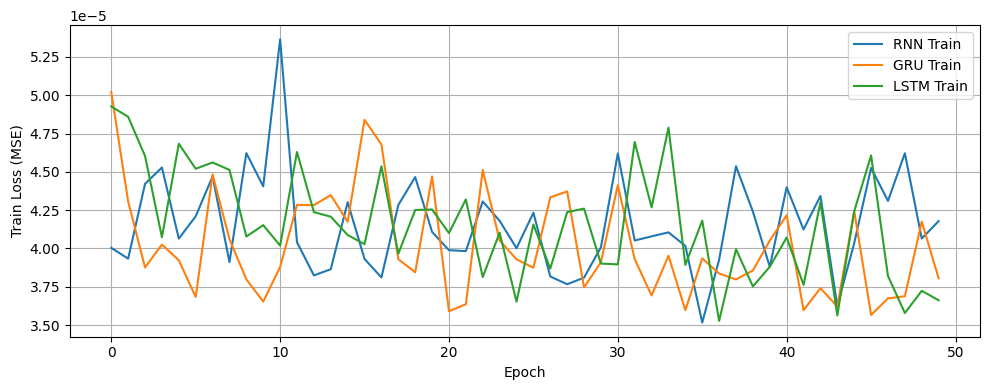

In [ ]:
models = {
    'RNN': model_RNN,
    'GRU': model_GRU,
    'LSTM': model_LSTM
}

# Запуск сравнения
# scaler — ваш объект масштабирования (MinMaxScaler/StandardScaler), если нужно инвертировать метрики
df, histories = compare_models_on_test(models, train_loader, test_loader, device=device, scaler=None)

Видим, что по графику можно судить о неравномерности обучения моделей - это может быть связано с затуханием и взрывом градиента, что после какого-то шага в обучающей функции фиксится dropout или другими функциями, борящимися с переобучением и этими проблемами.


Лучше всего на наших выборках себя показала RNN

## Подбор гипрепараметров для лучшей модели

Поменяем параметры при инициализации и посмотрим на результат loss на тех же данных

In [ ]:
model = RNN(input_size=1, hidden_size=2, num_layers=6, dropout=0.5).to(device)

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model_RNN.parameters(), lr=0.001)
epochs = 50

model_RNN.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        predictions = model_RNN(X_batch)
        loss = criterion(predictions, y_batch)

        loss.backward()

        # 🔥 Обрезка градиентов: обязательна для RNN/LSTM, чтобы избежать взрыва градиентов
        torch.nn.utils.clip_grad_norm_(model_RNN.parameters(), max_norm=1.0)

        optimizer.step()
        epoch_loss += loss.item() * X_batch.size(0)

    avg_loss = epoch_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.6f}")

Epoch 1/50 | Loss: 0.000043
Epoch 2/50 | Loss: 0.000037
Epoch 3/50 | Loss: 0.000038
Epoch 4/50 | Loss: 0.000040
Epoch 5/50 | Loss: 0.000038
Epoch 6/50 | Loss: 0.000039
Epoch 7/50 | Loss: 0.000044
Epoch 8/50 | Loss: 0.000041
Epoch 9/50 | Loss: 0.000040
Epoch 10/50 | Loss: 0.000040
Epoch 11/50 | Loss: 0.000040
Epoch 12/50 | Loss: 0.000044
Epoch 13/50 | Loss: 0.000041
Epoch 14/50 | Loss: 0.000038
Epoch 15/50 | Loss: 0.000041
Epoch 16/50 | Loss: 0.000040
Epoch 17/50 | Loss: 0.000046
Epoch 18/50 | Loss: 0.000036
Epoch 19/50 | Loss: 0.000040
Epoch 20/50 | Loss: 0.000038
Epoch 21/50 | Loss: 0.000036
Epoch 22/50 | Loss: 0.000040
Epoch 23/50 | Loss: 0.000042
Epoch 24/50 | Loss: 0.000039
Epoch 25/50 | Loss: 0.000039
Epoch 26/50 | Loss: 0.000039
Epoch 27/50 | Loss: 0.000042
Epoch 28/50 | Loss: 0.000040
Epoch 29/50 | Loss: 0.000039
Epoch 30/50 | Loss: 0.000038
Epoch 31/50 | Loss: 0.000038
Epoch 32/50 | Loss: 0.000041
Epoch 33/50 | Loss: 0.000039
Epoch 34/50 | Loss: 0.000039
Epoch 35/50 | Loss: 0.0

**Получили улучшение качества модели, так как loss стал ниже, следовательно подбор гиперпараметров(изменение dropout, learning_rate и т.д) а также выбор критерия и функции оптимизации приводит к улучшению**